In [27]:
from typing import Dict, List, Any, Tuple
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking import (
    get_summary_results, 
    results_to_arrays,
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations_with_norm,
    correlation_table,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm
from model_ranking import (
    calculate_correlation_statistics
)

In [39]:
NA_UNet_source_models = {
    "PNAS": "p_model_NA1",
    "Ovules": "ov_model_NA1",
}
Res_source_models = {
    "FlyWing": "fw_model_Res2",
    "Ovules": "ov_model_Res1",
    "PNAS": "p_model_Res1",
}

Unetr_source_models = {
    "FlyWing": "fw_model_Unetr2",
    "Ovules": "ov_model_Unetr1",
    "PNAS": "p_model_Unetr1",
}
Unet_source_models={
    "FlyWing": "fw_model_Unet2",
    "Ovules": "ov_model_UNet1",
    "PNAS": "p_model_UNet1",
}

consis_keys={
    "FlyWing": "weighted_AdaRandError_consis",
    "Ovules": "weighted_AdaRandError_consis",
}
# consis_keys_bckg = {
#     "FlyWing": "AdaRandError_consis_bckg",
#     "Ovules": "AdaRandError_consis_bckg",
#     "PNAS": "AdaRandError_consis_bckg",
# }
result_folders={
    "FlyWing": "P_fullslice",
    "Ovules": "P_fullslice",
    "PNAS": "P_full",
}

per_target_norms: Dict[str, List[Tuple[float,float]]] = {
    "FlyWing": [(5.0, 95.0)],
    "Ovules": [(5.0, 95.0)],
    "PNAS": [(5.0, 95.0)],
}

perf_key = "MAP_05_095"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [40]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
}

targets = ["FlyWing", "Ovules"]

#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [Unet_source_models, NA_UNet_source_models,  Res_source_models]

In [41]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
sources = ["FlyWing", "Ovules", "PNAS"]
for i, target in enumerate(targets):
        
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "NA" in model_type["PNAS"]:
            sources = ["Ovules", "PNAS"]
        
        else:
            sources = ["FlyWing", "Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            #consis_postfix="median",
            consis_postfix=None,
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: FlyWing


100%|██████████| 1/1 [00:00<00:00, 28.91it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 27.99it/s]


Source: PNAS


...

100%|██████████| 1/1 [00:00<00:00, 38.09it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 37.91it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 38.48it/s]


# Fullslice weighted average

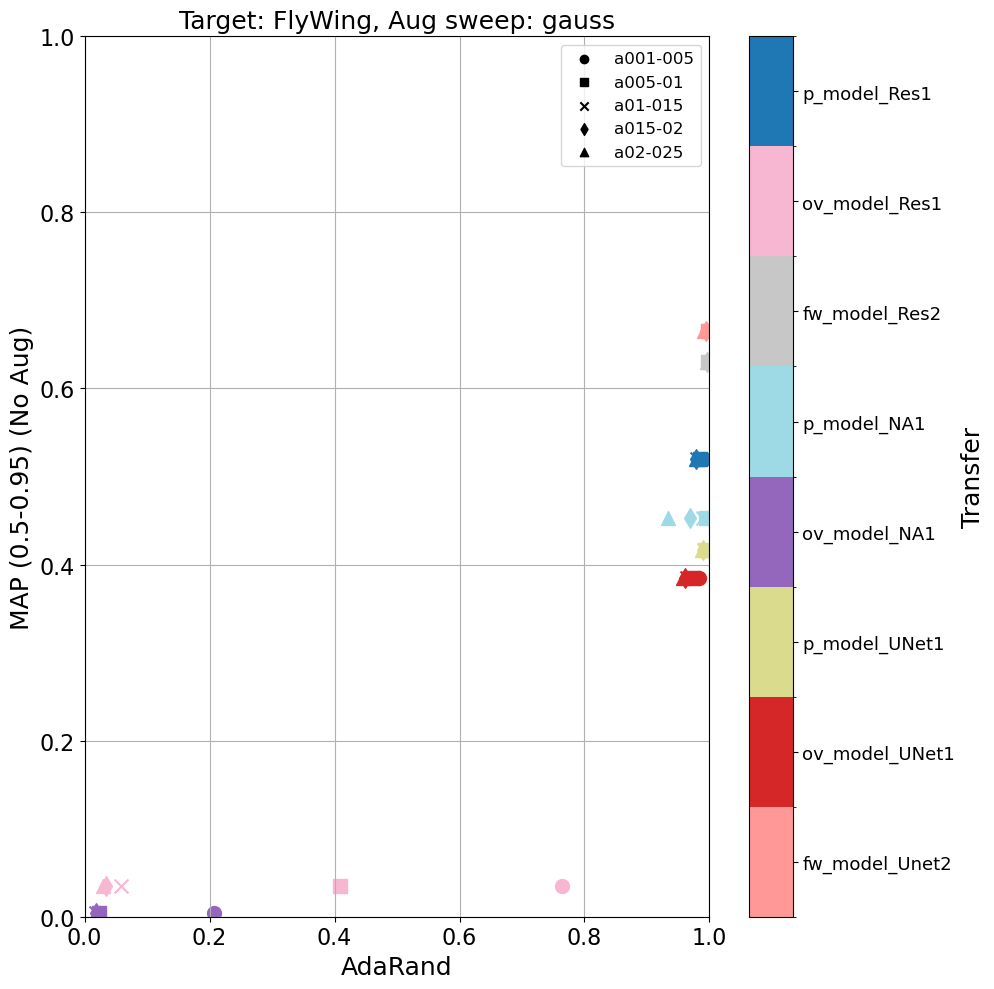

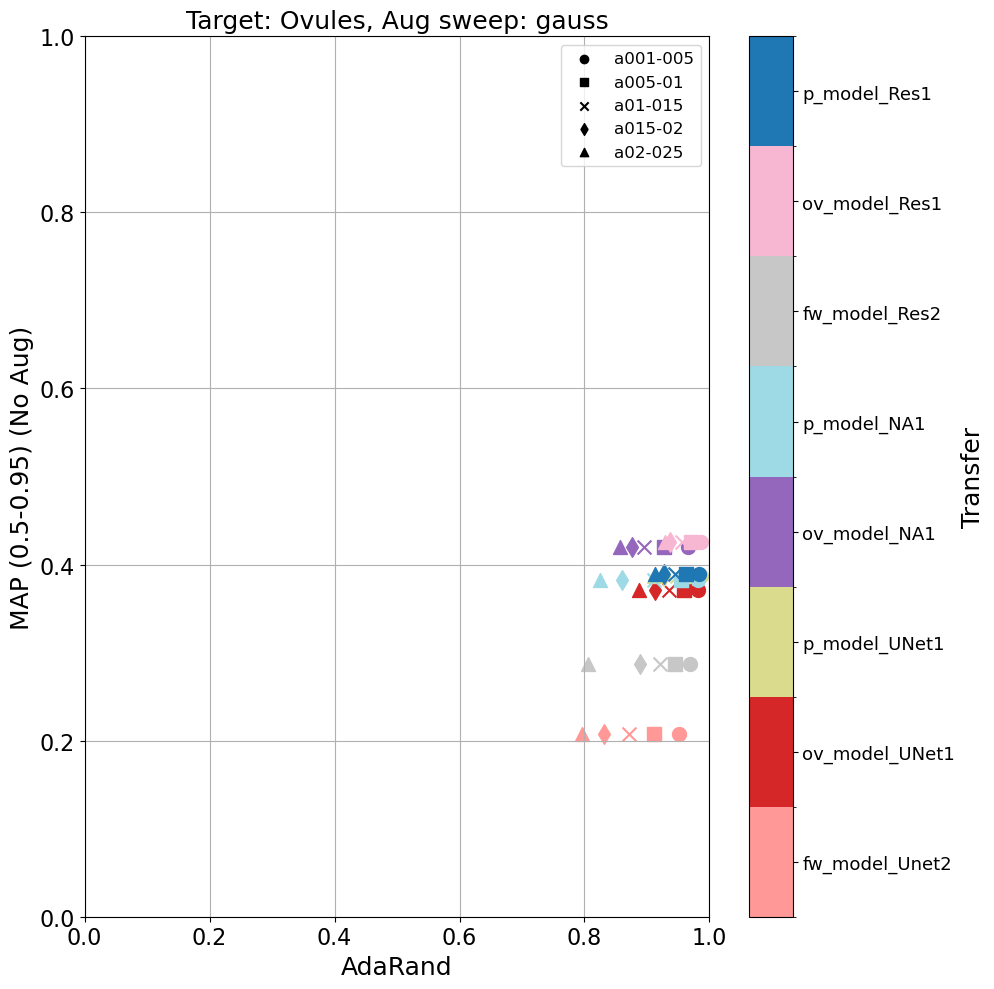

In [42]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [43]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss",
    invert_consis_score=True,
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.80     0.02   0.90        0.00  0.79     0.01
     Ovules   0.78     0.02   0.52        0.22  0.43     0.19
gauss: a005-01
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.90     0.00   0.90        0.01  0.79     0.01
     Ovules   0.67     0.07   0.52        0.19  0.43     0.18
gauss: a01-015
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.90        0.01  0.79     0.01
     Ovules   0.65     0.08   0.55        0.19  0.43     0.17
gauss: a015-02
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.93     0.00   0.90        0.01  0.79     0.01
     Ovul

# Save_results

In [44]:
per_target_consistency_a001_a005: Dict[str, Dict[str,float]] = {}
per_target_consistency_a005_a01: Dict[str, Dict[str,float]] = {}
per_target_consistency_a01_a015: Dict[str, Dict[str,float]] = {}
per_target_consistency_a015_a02: Dict[str, Dict[str,float]] = {}
per_target_consistency_a02_a025: Dict[str, Dict[str,float]] = {}
for target, per_model_consistency in per_target_forg_consistency.items():
    per_target_consistency_a001_a005[target] = {}
    per_target_consistency_a005_a01[target] = {}
    per_target_consistency_a01_a015[target] = {}
    per_target_consistency_a015_a02[target] = {}
    per_target_consistency_a02_a025[target] = {}
    for model, consistency in per_model_consistency.items():
        per_target_consistency_a001_a005[target][model] = consistency['norm_50_950']['gauss'][0]
        per_target_consistency_a005_a01[target][model] = consistency['norm_50_950']['gauss'][1]
        per_target_consistency_a01_a015[target][model] = consistency['norm_50_950']['gauss'][2]
        per_target_consistency_a015_a02[target][model] = consistency['norm_50_950']['gauss'][3]
        per_target_consistency_a02_a025[target][model] = consistency['norm_50_950']['gauss'][4]

In [45]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_50_950']
        else:
            per_target_performance[target][model] = performance

In [52]:
import json
import os
from model_ranking import convert_numpy_types
save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg"
if not os.path.exists(save_path):
    os.makedirs(save_path)
with open(os.path.join(save_path, "transfer_Gauss_a02-a025_CMB_05f_05b_ARE_scores.json"), "w") as f:
    results: Dict[str, Any] = {
        "transfer_scores": convert_numpy_types(per_target_consistency_a02_a025),
    }
    json.dump(results, f, indent=4)

# Fullslice

In [33]:
consis_keys={
    "FlyWing": "AdaRandError_consis",
    "Ovules": "AdaRandError_consis",
    "PNAS": "AdaRandError_consis",
}

In [34]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
sources = ["FlyWing", "Ovules", "PNAS"]
for i, target in enumerate(targets):
        
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "NA" in model_type["PNAS"]:
            sources = ["Ovules", "PNAS"]
        
        else:
            sources = ["FlyWing", "Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: FlyWing


100%|██████████| 1/1 [00:00<00:00, 31.86it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 34.36it/s]


Source: PNAS


...

100%|██████████| 1/1 [00:00<00:00, 38.13it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 37.06it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 36.74it/s]


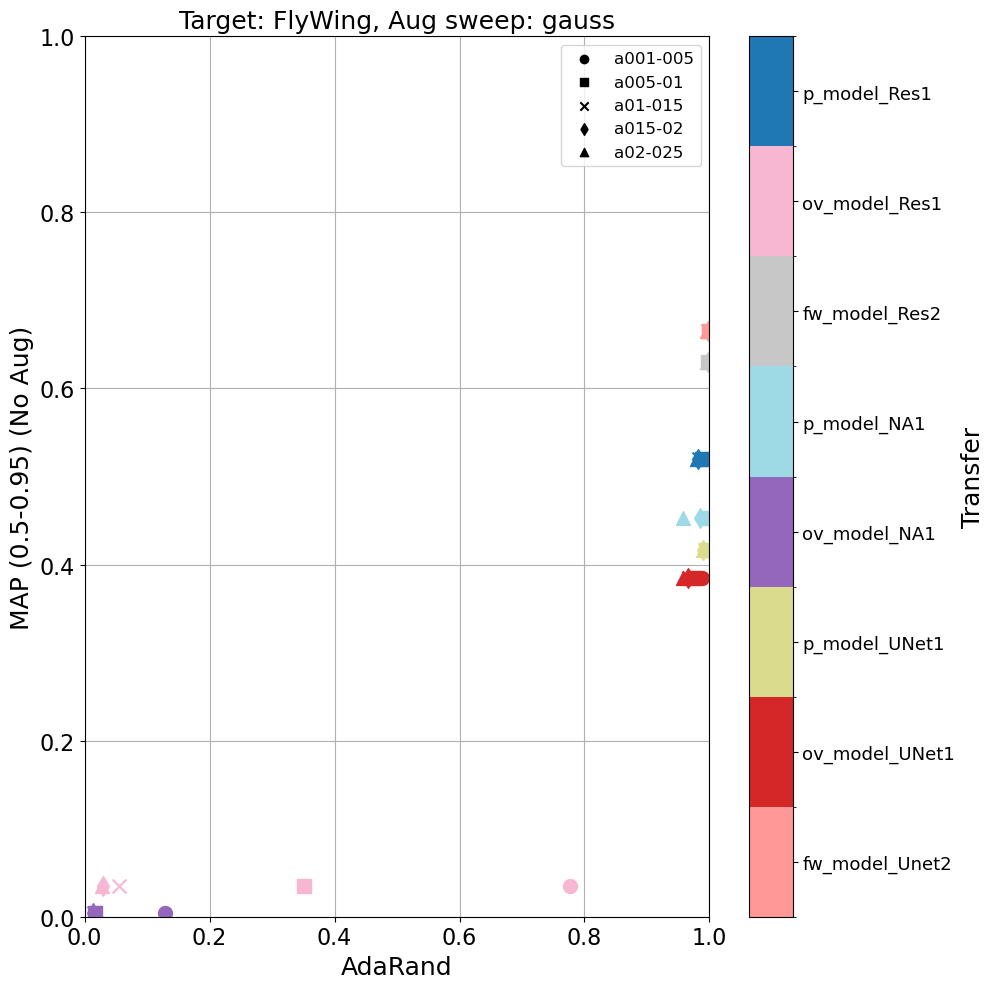

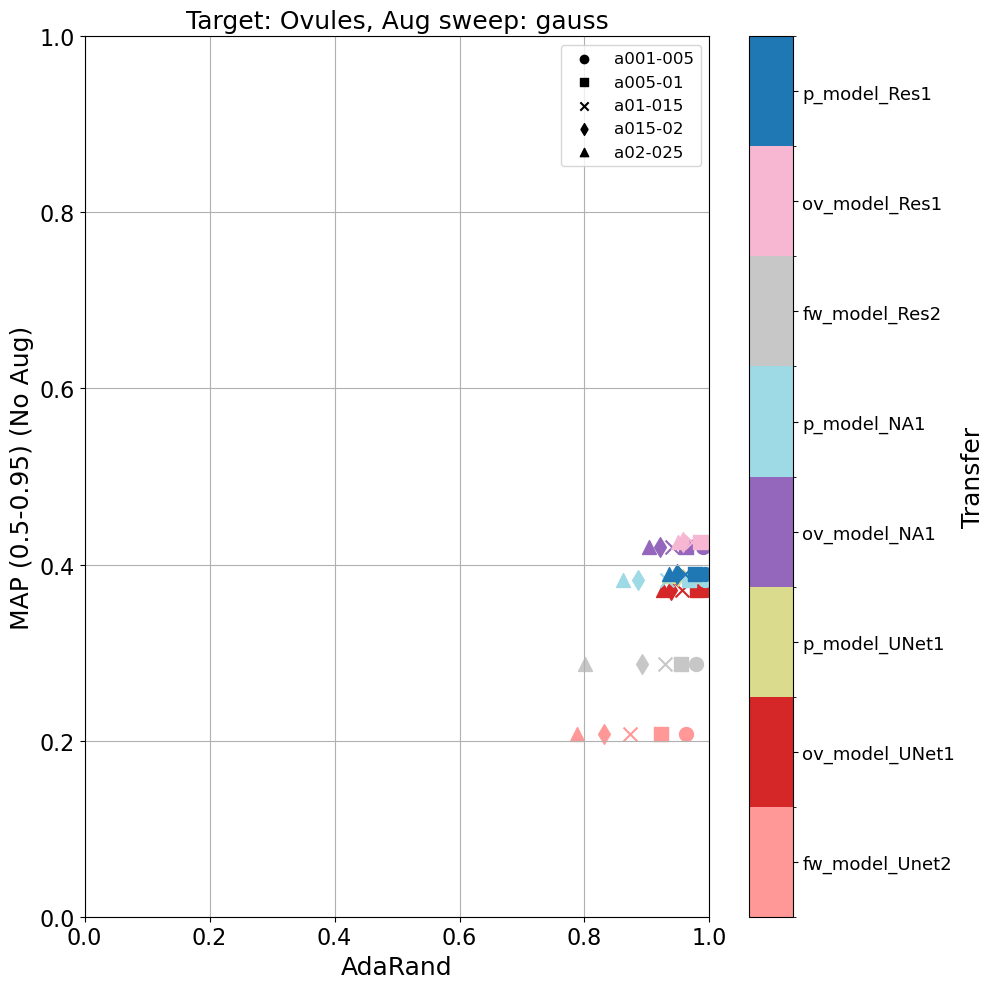

In [35]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

# Save_results

In [36]:
per_target_consistency_a001_a005: Dict[str, Dict[str,float]] = {}
per_target_consistency_a005_a01: Dict[str, Dict[str,float]] = {}
per_target_consistency_a01_a015: Dict[str, Dict[str,float]] = {}
per_target_consistency_a015_a02: Dict[str, Dict[str,float]] = {}
per_target_consistency_a02_a025: Dict[str, Dict[str,float]] = {}
for target, per_model_consistency in per_target_forg_consistency.items():
    per_target_consistency_a001_a005[target] = {}
    per_target_consistency_a005_a01[target] = {}
    per_target_consistency_a01_a015[target] = {}
    per_target_consistency_a015_a02[target] = {}
    per_target_consistency_a02_a025[target] = {}
    for model, consistency in per_model_consistency.items():
        per_target_consistency_a001_a005[target][model] = consistency['norm_50_950']['gauss'][0]
        per_target_consistency_a005_a01[target][model] = consistency['norm_50_950']['gauss'][1]
        per_target_consistency_a01_a015[target][model] = consistency['norm_50_950']['gauss'][2]
        per_target_consistency_a015_a02[target][model] = consistency['norm_50_950']['gauss'][3]
        per_target_consistency_a02_a025[target][model] = consistency['norm_50_950']['gauss'][4]

In [18]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_50_950']
        else:
            per_target_performance[target][model] = performance

In [ ]:
# import json
# import os
# from model_ranking import convert_numpy_types
# save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice"
# if not os.path.exists(save_path):
#     os.makedirs(save_path)
# with open(os.path.join(save_path, "transfer_performance_scores_with_NORM.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_forg_performance),
#     }
#     json.dump(results, f, indent=4)